# Setup

In [1]:
%load_ext autoreload
%autoreload 2
%cd -q ..
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Workaround for scenario definition restructure.
import impl.ads.mr.mr as base_mr_module
import impl.ads.scenario.scenario_definition as scen_def_module

sys.modules["impl.scenario.scenario_definition"] = scen_def_module
sys.modules["impl.mr.mr"] = base_mr_module

from impl.ads.utils.explain import vectorize, generate_rules, model_fit, scoring

OUT_DIR = Path("out/exp_results/")

# Prepare data

In [2]:
exp_data = {
    'ccea-c': [
        '1748884695969-ccea-d240fc',
        '1748941748026-ccea-b9ac6b',
        '1748989829337-ccea-4ec741',
        '1749038770422-ccea-42ed4d',
        '1749777922892-ccea-2c25d2',
        '1749814642920-ccea-de1f87',
        '1749886823824-ccea-649444',
        '1749923655258-ccea-1ba284',
        '1751198102877-ccea-1addfe',
        '1751208800030-ccea-a4ce3b',
    ],
    'ccea': [
        '1753244710641-ccea-37da0a',
        '1753253587969-ccea-3f4538',
        '1753265201843-ccea-8736f6',
        '1753277995878-ccea-4f4a93',
        '1753288312696-ccea-90131b',
        '1753299743510-ccea-2fe213',
        '1753311062286-ccea-c5ffb6',
        '1753325640117-ccea-cbdc64',
        '1753337580322-ccea-4028eb',
        '1753350065570-ccea-bfd2a8',
    ],
    'ga': [
        '1748973401212-ga-159d20',
        '1749020894373-ga-0c91c0',
        '1749070990957-ga-e5c457',
        '1749117177309-ga-e90e3a',
        '1749801622497-ga-1bf740',
        '1749865564502-ga-d4aeee',
        '1749911224188-ga-398954',
        '1749948108048-ga-cf2ad2',
        '1755546683848-ga-ae4399',
        '1755582174116-ga-4c68ce',
    ],
    'rs': [
        '1748904187579-rs-eb1239',
        '1749004788416-rs-6bf5f1',
        '1749054600895-rs-2ed24b',
        '1749101043616-rs-24f811',
        '1749789337635-rs-395f0a',
        '1749852996207-rs-73049d',
        '1749897744564-rs-122ef9',
        '1749934847144-rs-a62c00',
        '1755533345878-rs-34b8ed',
        '1755568778720-rs-1f9a96',
    ],
    'ccea-c+ri': [
        '1750434085129-ccea-ddb606',
        '1750449704726-ccea-5b378e',
        '1750463599493-ccea-3174c7',
        '1750474241344-ccea-de114c',
        '1750486589729-ccea-d7ee1e',
        '1750497161663-ccea-e0eee8',
        '1751223236951-ccea-ca103a',
        '1751231897173-ccea-a652fa',
        '1751243485332-ccea-36643e',
        '1751274772053-ccea-ac5042',
    ],
    'ccea+ri': [
        '1750785163861-ccea-21aab6',
        '1750803393939-ccea-e46291',
        '1750816760201-ccea-a491e1',
        '1750840993246-ccea-b56d46',
        '1750874763838-ccea-c37984',
        '1751052499693-ccea-37549d',
        '1751064557270-ccea-8d3741',
        '1751327671761-ccea-fa8901',
        '1755655938747-ccea-dc4280',
        '1755673172607-ccea-248354',
    ],
    'ccea-budget500': [
        '1753629887471-ccea-a574d1',
        '1753655503296-ccea-c22942',
        '1753682701323-ccea-ad3eab',
        '1753709801308-ccea-075fce',
        '1753734302443-ccea-ef5412',
        '1753755439514-ccea-7faff3',
        '1753799557159-ccea-e68788',
        '1753826910130-ccea-363aca',
        '1753861383229-ccea-9ab0f8',
    ],
    'ga-budget500': [
        '1753986957882-ga-c72b04',
        '1754205177517-ga-a3535a',
        '1754284712018-ga-539f97',
        '1754355391649-ga-2b0c39',
        '1754492634229-ga-c7ba05',
        '1754558445884-ga-e5fb67',
        '1754625896055-ga-9d5c89',
        '1754693081446-ga-3c5903',
        '1754766932867-ga-b3561f',
        '1754797643721-ga-46e0c3',
    ],
    'rs-budget500': [
        '1754073826949-rs-f3eebf',
        '1754113994059-rs-b5e6b4',
        '1754324591780-rs-8182a5',
        '1754399240427-rs-061866',
        '1754460587756-rs-a9f563',
        '1754526105694-rs-684a1a',
        '1754594586253-rs-e2b4b0',
        '1754660930610-rs-d94e3d',
        '1754735354981-rs-9af071',
        '1754811501780-rs-a3f214',
    ],
}

projects = [proj for proj_list in exp_data.values() for proj in proj_list]
violations, non_violations = [], []
for project in projects:
    for solution_file in Path("out/results", project, "solutions").rglob("evaluated*"):
        for solution in pickle.loads(solution_file.read_bytes()):
            if solution.is_violated:
                violations.append(solution)
            elif not solution.is_violated and solution.fitness.valid:
                non_violations.append(solution)
if len(non_violations) > len(violations):
    import random

    non_violations = random.sample(non_violations, len(violations))
solutions = violations + non_violations
print(f"#violations: {len(violations)}, #non-violations: {len(non_violations)}, total: {len(solutions)}")

#violations: 1321, #non-violations: 915, total: 2236


# Vectorization

In [3]:
X, y, y_v1, y_v2, features = vectorize(solutions, mode="stats")

# Train models

2025-08-22 13:48:24,585     INFO     5798 --- 
RANDOMIZED SEARCH
================================================== (explain.py:112)
2025-08-22 13:48:24,588     INFO     5798 --- Using RandomizedSearchCV with 100 iterations... (explain.py:134)
2025-08-22 13:48:24,588     INFO     5798 --- Starting randomized search... (explain.py:147)
Fitting 5 folds for each of 100 candidates, totalling 500 fits


tostring() is deprecated. Use tobytes() instead.


2025-08-22 13:51:36,940     INFO     5798 --- Randomized search completed! (explain.py:150)
2025-08-22 13:51:36,941     INFO     5798 --- Best CV RMSE: 1.001566 (explain.py:151)
2025-08-22 13:51:36,942     INFO     5798 --- 
Best parameters:
	colsample_bytree    : 0.7599443886861021
	learning_rate       : 0.01886647601058693
	max_depth           : 6
	min_child_weight    : 7
	n_estimators        : 239
	reg_alpha           : 0.0906064345328208
	reg_lambda          : 1.427579013999631
	subsample           : 0.7529847965068651 (explain.py:155)
2025-08-22 13:51:36,943     INFO     5798 --- 
RANDOMIZED SEARCH ANALYSIS
================================================== (explain.py:157)
2025-08-22 13:51:36,949     INFO     5798 --- 
Top 5 parameter combinations:
	1. RMSE: 1.001566 - {'colsample_bytree': 0.7599443886861021, 'learning_rate': 0.01886647601058693, 'max_depth': 6, 'min_child_weight': 7, 'n_estimators': 239, 'reg_alpha': 0.0906064345328208, 'reg_lambda': 1.427579013999631, 'subsampl

tostring() is deprecated. Use tobytes() instead.


2025-08-22 13:51:40,236     INFO     5798 --- Cross-validation RMSE: 1.001566 (+/- 0.746042) (explain.py:200)
2025-08-22 13:51:40,248     INFO     5798 --- ✓ Best model saved as '/home/stk/projects/CoCoMEGA/out/exp_results/1755885100237/best_model.pkl'. (explain.py:207)
2025-08-22 13:51:40,265     INFO     5798 --- ✓ Randomized search results saved as '/home/stk/projects/CoCoMEGA/out/exp_results/1755885100237/search_results.pkl'. (explain.py:212)
2025-08-22 13:51:40,266     INFO     5798 --- 
MODEL VISUALIZATION
================================================== (explain.py:214)


tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprec

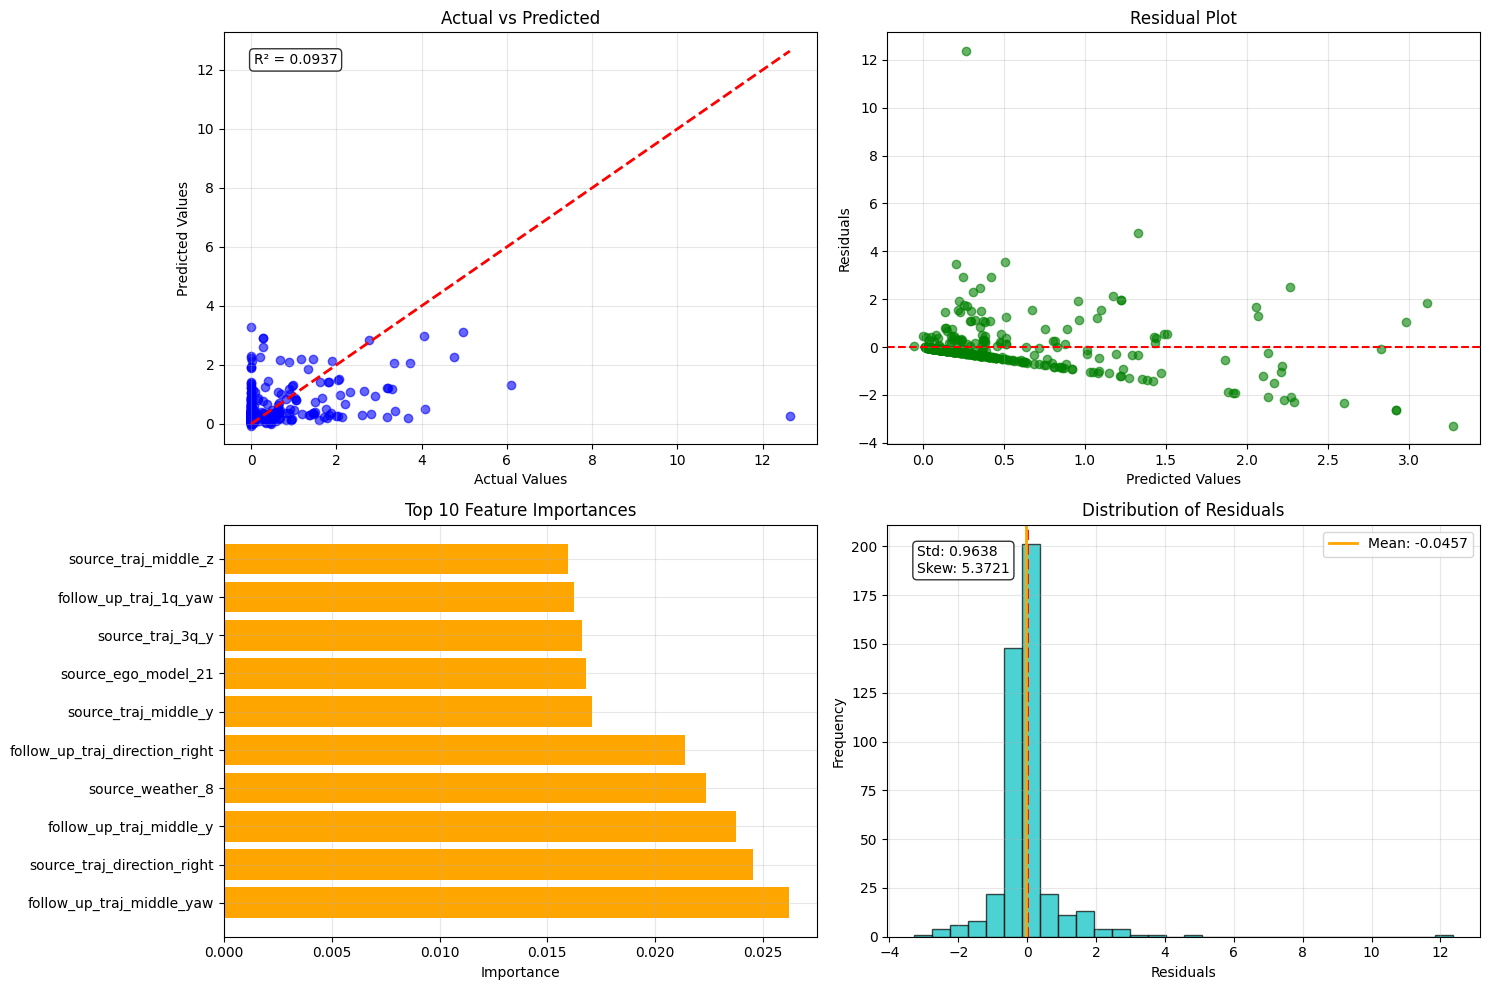

In [16]:
best_model_v1 = model_fit(X, y_v1)

2025-08-22 13:51:40,798     INFO     5798 --- 
RANDOMIZED SEARCH
================================================== (explain.py:112)
2025-08-22 13:51:40,802     INFO     5798 --- Using RandomizedSearchCV with 100 iterations... (explain.py:134)
2025-08-22 13:51:40,804     INFO     5798 --- Starting randomized search... (explain.py:147)
Fitting 5 folds for each of 100 candidates, totalling 500 fits


tostring() is deprecated. Use tobytes() instead.


2025-08-22 13:54:54,101     INFO     5798 --- Randomized search completed! (explain.py:150)
2025-08-22 13:54:54,102     INFO     5798 --- Best CV RMSE: 0.854183 (explain.py:151)
2025-08-22 13:54:54,103     INFO     5798 --- 
Best parameters:
	colsample_bytree    : 0.6326376721600961
	learning_rate       : 0.010985123927057487
	max_depth           : 6
	min_child_weight    : 5
	n_estimators        : 69
	reg_alpha           : 0.6499639307777652
	reg_lambda          : 1.552950315886555
	subsample           : 0.9183170677744404 (explain.py:155)
2025-08-22 13:54:54,104     INFO     5798 --- 
RANDOMIZED SEARCH ANALYSIS
================================================== (explain.py:157)
2025-08-22 13:54:54,108     INFO     5798 --- 
Top 5 parameter combinations:
	1. RMSE: 0.854183 - {'colsample_bytree': 0.6326376721600961, 'learning_rate': 0.010985123927057487, 'max_depth': 6, 'min_child_weight': 5, 'n_estimators': 69, 'reg_alpha': 0.6499639307777652, 'reg_lambda': 1.552950315886555, 'subsampl

tostring() is deprecated. Use tobytes() instead.


2025-08-22 13:54:55,039     INFO     5798 --- Cross-validation RMSE: 0.854183 (+/- 0.681816) (explain.py:200)
2025-08-22 13:54:55,047     INFO     5798 --- ✓ Best model saved as '/home/stk/projects/CoCoMEGA/out/exp_results/1755885295040/best_model.pkl'. (explain.py:207)
2025-08-22 13:54:55,063     INFO     5798 --- ✓ Randomized search results saved as '/home/stk/projects/CoCoMEGA/out/exp_results/1755885295040/search_results.pkl'. (explain.py:212)
2025-08-22 13:54:55,064     INFO     5798 --- 
MODEL VISUALIZATION
================================================== (explain.py:214)


tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprecated. Use tobytes() instead.
tostring() is deprec

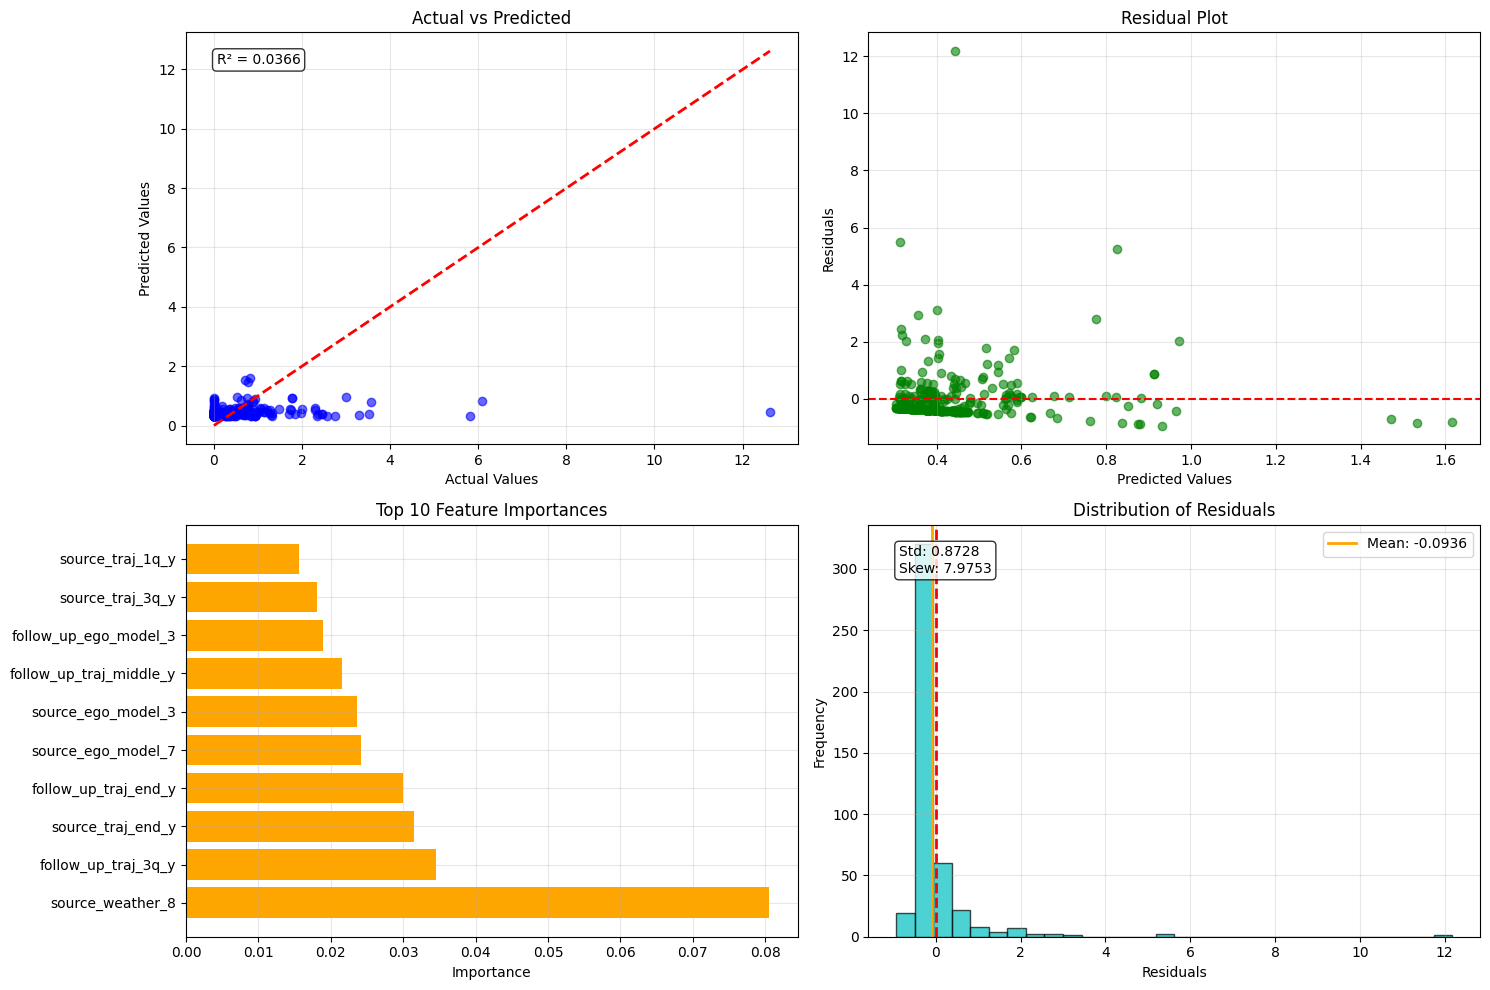

In [17]:
best_model_v2 = model_fit(X, y_v2)

# Load models

In [4]:
import joblib

best_model_v1 = joblib.load(OUT_DIR / "1755885100237" / "best_model.pkl")
best_model_v2 = joblib.load(OUT_DIR / "1755885295040" / "best_model.pkl")

# RuleFit

In [ ]:
rulefit = generate_rules(X, y, features)
rules = rulefit._get_rules()
rules[rules.coef != 0].sort_values("importance", ascending=False).style.background_gradient(cmap="viridis")

# RQ4: MASE comparison

In [6]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split


def _randomized_search(_X, _y, _model, _param_dist):
    _X_train, _X_test, _y_train, _y_test = train_test_split(_X, np.array(_y), test_size=0.2, random_state=42)
    print("Using RandomizedSearchCV with 100 iterations...")
    _random_search = RandomizedSearchCV(
        estimator=_model(random_state=42),
        param_distributions=_param_dist,
        n_iter=100,
        scoring="r2",
        cv=5,
        n_jobs=-1,
        verbose=1,
        random_state=42,
        return_train_score=True,
    )
    print("Starting randomized search...")
    _random_search.fit(_X_train, _y_train)
    print("Randomized search completed!")
    print("Best parameters:")
    for _param, _value in _random_search.best_params_.items():
        print(f"\t{_param:<20}: {_value}")

In [73]:
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint, uniform

_randomized_search(X, y, RandomForestRegressor, {
    "n_estimators": randint(100, 301),
    "max_leaf_nodes": randint(3, 11),
    "max_depth": randint(3, 101),
    "min_samples_leaf": randint(1, 11),
    "max_features": uniform(0.1, 0.9),
    "criterion": ["squared_error", "absolute_error"],
})

Using RandomizedSearchCV with 100 iterations...
Starting randomized search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits


tostring() is deprecated. Use tobytes() instead.


Randomized search completed!
Best parameters:
	criterion           : squared_error
	max_depth           : 6
	max_features        : 0.6542660479509225
	max_leaf_nodes      : 10
	min_samples_leaf    : 7
	n_estimators        : 101


In [74]:
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import randint, uniform

_randomized_search(X, y, GradientBoostingRegressor, {
    "n_estimators": randint(100, 301),
    "max_leaf_nodes": randint(3, 11),
    "max_depth": randint(3, 101),
    "min_samples_leaf": randint(1, 11),
    "learning_rate": uniform(0.01, 0.19),
    "subsample": uniform(0.6, 0.4),
    "criterion": ["friedman_mse", "squared_error"],
    "loss": ["squared_error", "huber"]
})

Using RandomizedSearchCV with 100 iterations...
Starting randomized search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits


tostring() is deprecated. Use tobytes() instead.


Randomized search completed!
Best parameters:
	criterion           : squared_error
	learning_rate       : 0.029279593144546104
	loss                : squared_error
	max_depth           : 27
	max_leaf_nodes      : 7
	min_samples_leaf    : 2
	n_estimators        : 227
	subsample           : 0.7221455441377573


In [11]:
from collections import defaultdict
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from imodels import RuleFitRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split


def _get_leaf_paths(_tree):
    _children_left = _tree.tree_.children_left
    _children_right = _tree.tree_.children_right
    _path_lengths = []

    def _dfs(_node, _depth):
        if _children_left[_node] == -1 and _children_right[_node] == -1:
            _path_lengths.append(_depth)
            return
        if _children_left[_node] != -1:
            _dfs(_children_left[_node], _depth + 1)
        if _children_right[_node] != -1:
            _dfs(_children_right[_node], _depth + 1)

    _dfs(0, 0)
    return _path_lengths


metrics = defaultdict(lambda: defaultdict(list))
for _ in range(500):
    X_train, X_val, y_train, y_val = train_test_split(X, np.array(y), test_size=0.2)

    # Baseline
    y_pred_median = np.full_like(y_val, fill_value=np.median(y_train))
    mae_baseline = mean_absolute_error(y_val, y_pred_median)
    metrics["baseline"]["mae"].append(mae_baseline)

    # RuleFit
    rulefit = RuleFitRegressor(max_rules=30)
    rulefit.fit(X_train, y_train)
    y_pred_rulefit = rulefit.predict(X_val)
    mae_rulefit = mean_absolute_error(y_val, y_pred_rulefit)
    metrics["rulefit"]["mae"].append(mae_rulefit)
    metrics["rulefit"]["mase"].append(mae_rulefit / mae_baseline)
    rules = rulefit._get_rules()
    rules = rules[rules.coef != 0]
    metrics["rulefit"]["rule"].append(rules)
    feature_counts = []
    for _, row in rules.iterrows():
        if row["rule"] == "linear": feature_counts.append(1)
        feature_counts.append(len(row["rule"].split("and")))
    metrics["rulefit"]["size"].append(len(rules))
    metrics["rulefit"]["length"].append(feature_counts)

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=101,
        max_depth=6,
        max_leaf_nodes=10,
        min_samples_leaf=7,
        max_features=0.6542660479509225,
        criterion="squared_error",
    )
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_val)
    mae_rf = mean_absolute_error(y_val, y_pred_rf)
    metrics["rf"]["mae"].append(mae_rf)
    metrics["rf"]["mase"].append(mae_rf / mae_baseline)
    n_leaves_rf = sum(est.tree_.n_leaves for est in rf.estimators_)
    metrics["rf"]["size"].append(n_leaves_rf)
    path_lengths_rf = [length for est in rf.estimators_ for length in _get_leaf_paths(est)]
    metrics["rf"]["length"].append(path_lengths_rf)
    assert n_leaves_rf == len(path_lengths_rf)

    # GBDT
    gbdt = GradientBoostingRegressor(
        n_estimators=227,
        max_depth=27,
        max_leaf_nodes=7,
        min_samples_leaf=2,
        subsample=0.7221455441377573,
        learning_rate=0.029279593144546104,
        criterion="squared_error",
        loss="squared_error",
    )
    gbdt.fit(X_train, y_train)
    y_pred_gbdt = gbdt.predict(X_val)
    mae_gbdt = mean_absolute_error(y_val, y_pred_gbdt)
    metrics["gbdt"]["mae"].append(mae_gbdt)
    metrics["gbdt"]["mase"].append(mae_gbdt / mae_baseline)
    n_leaves_gbdt = sum(est[0].tree_.n_leaves for est in gbdt.estimators_)
    metrics["gbdt"]["size"].append(n_leaves_gbdt)
    path_lengths_gbdt = [length for est in gbdt.estimators_ for length in _get_leaf_paths(est[0])]
    metrics["gbdt"]["length"].append(path_lengths_gbdt)
    assert n_leaves_gbdt == len(path_lengths_gbdt)

(OUT_DIR / "mae.pkl").write_bytes(pickle.dumps(dict(metrics)))

5228377

In [5]:
metrics = pickle.loads((OUT_DIR / "mae.pkl").read_bytes())

========== RuleFit ==========
Avg. MAE:			0.43878935385795337
Avg. #rules:		28.64
Avg. rule length:	2.12
========== RF ==========
Avg. MAE:			0.40087951651786985
Avg. #rules:		1009.99
Avg. rule length:	3.78
========== GBDT ==========
Avg. MAE:			0.4180800196301831
Avg. #rules:		1589.00
Avg. rule length:	3.27


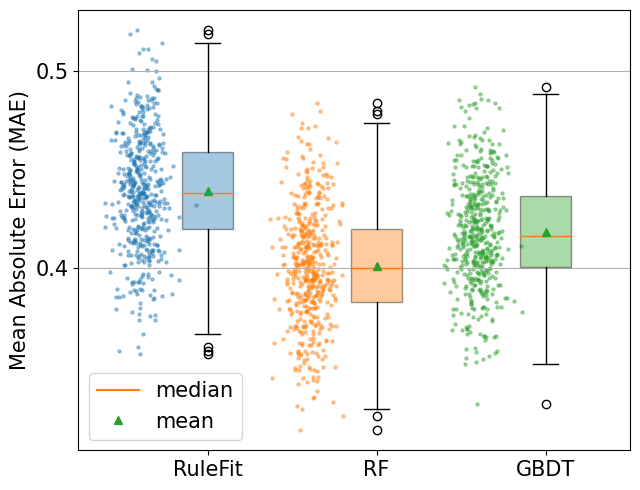

In [54]:
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

height = 5
text_size, tick_size = height * 3, height * 3
fig, ax = plt.subplots(figsize=(height * 1.3, height))
labels = ["RuleFit", "RF", "GBDT"]
values = [metrics[alg.lower()]["mae"] for alg in labels]
for alg in labels:
    print(f"========== {alg} ==========")
    print(f"Avg. MAE:\t\t\t{np.mean(metrics[alg.lower()]['mae'])}")
    print(f"Avg. #rules:\t\t{np.mean(metrics[alg.lower()]['size']):.2f}")
    print(f"Avg. rule length:\t{np.mean([np.mean(lengths) for lengths in metrics[alg.lower()]['length']]):.2f}")
bplot = ax.boxplot(values, labels=labels, showmeans=True, patch_artist=True)
for patch, color in zip(bplot["boxes"], [f"C{i}" for i in range(10)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)
for i, value in enumerate(values):
    ax.scatter(np.random.normal(i + 0.6, 0.08, len(value)), value, alpha=0.4, s=5)
ax.grid(axis="y")
ax.tick_params(labelsize=tick_size)
ax.yaxis.set_major_locator(MultipleLocator(0.1))
ax.set_ylabel("Mean Absolute Error (MAE)", fontsize=text_size)
ax.legend(handles=[
    Line2D([0], [0], c="C1", label="median"),
    Line2D([0], [0], ls="None", marker="^", mfc="C2", mec="C2", label="mean")
], fontsize=text_size)
plt.tight_layout()
plt.savefig(OUT_DIR / ".." / "visualizations" / "mae.pdf")

# RQ4: Support for the rules

In [55]:
ny = np.array(y)
X_vio = X[ny != 0]
support = []
for rule_df in metrics["rulefit"]["rule"]:
    non_linear_rules = rule_df[rule_df.type != "linear"]
    unique = set()
    for i, row in non_linear_rules.iterrows():
        rule = row["rule"]
        satisfied = X_vio.query(rule)
        unique |= set(satisfied.index)
    support.append(len(unique) / len(X_vio))

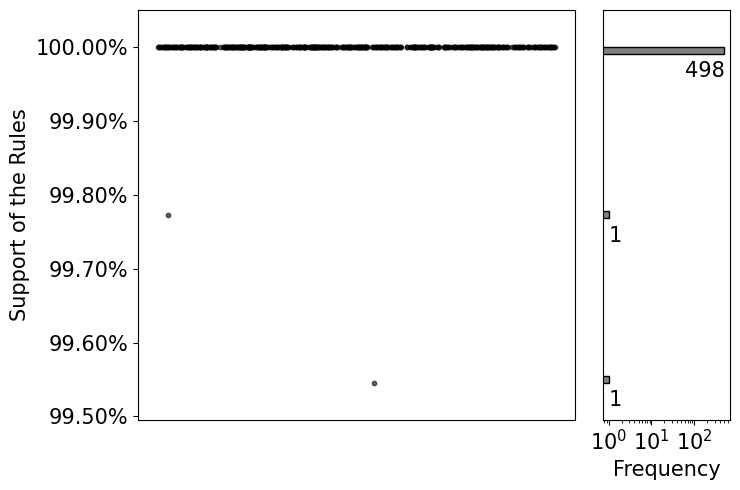

In [56]:
from matplotlib.ticker import PercentFormatter

data_x = np.random.rand(len(support))
data_y = np.array(support)
y_min = np.min(data_y)
y_max = np.max(data_y)

height = 5
text_size, tick_size = height * 3, height * 3
fig = plt.figure(figsize=(height * 1.5, height))
ax_scatter = plt.subplot2grid((4, 4), (0, 0), colspan=3, rowspan=4)
ax_hist_y = plt.subplot2grid((4, 4), (0, 3), rowspan=4)

ax_scatter.scatter(data_x, data_y, c="k", marker="o", s=10, alpha=0.6)
ax_scatter.set_ylabel("Support of the Rules", fontsize=text_size)
padding = 0.0005
ax_scatter.set_ylim(y_min - padding, y_max + padding)
ax_scatter.yaxis.set_major_formatter(PercentFormatter(1.0))
ax_scatter.set_xticks([])
ax_scatter.tick_params(labelsize=tick_size)

hist, bin_edges, _ = ax_hist_y.hist(data_y, bins=np.linspace(y_min, y_max, 50),
                                    orientation="horizontal", log=True,
                                    color="gray", edgecolor="black")
ax_hist_y.set_ylim(y_min - padding, y_max + padding)
ax_hist_y.set_yticks([])
ax_hist_y.tick_params(labelsize=tick_size)
for i, (count, bin_edge) in enumerate(zip(hist, bin_edges[:-1])):
    if count > 0:
        ax_hist_y.text(count + 1, bin_edge - 0.0001, f"{int(count)}", c="black",
                       va="top", ha="right", fontsize=tick_size)
ax_hist_y.set_xlabel("Frequency", fontsize=text_size)
plt.tight_layout()
plt.savefig(OUT_DIR / ".." / "visualizations" / "support.pdf")

# RQ4: Consistency of importance

In [6]:
score, D, W = scoring(best_model_v1, best_model_v2, X)
score

NPY_ARRAY_UPDATEIFCOPY, NPY_ARRAY_INOUT_ARRAY, and NPY_ARRAY_INOUT_FARRAY are deprecated, use NPY_WRITEBACKIFCOPY, NPY_ARRAY_INOUT_ARRAY2, or NPY_ARRAY_INOUT_FARRAY2 respectively instead, and call PyArray_ResolveWritebackIfCopy before the array is deallocated, i.e. before the last call to Py_DECREF.
UPDATEIFCOPY detected in array_dealloc.  Required call to PyArray_ResolveWritebackIfCopy or PyArray_DiscardWritebackIfCopy is missing
NPY_ARRAY_UPDATEIFCOPY, NPY_ARRAY_INOUT_ARRAY, and NPY_ARRAY_INOUT_FARRAY are deprecated, use NPY_WRITEBACKIFCOPY, NPY_ARRAY_INOUT_ARRAY2, or NPY_ARRAY_INOUT_FARRAY2 respectively instead, and call PyArray_ResolveWritebackIfCopy before the array is deallocated, i.e. before the last call to Py_DECREF.
UPDATEIFCOPY detected in array_dealloc.  Required call to PyArray_ResolveWritebackIfCopy or PyArray_DiscardWritebackIfCopy is missing
NPY_ARRAY_UPDATEIFCOPY, NPY_ARRAY_INOUT_ARRAY, and NPY_ARRAY_INOUT_FARRAY are deprecated, use NPY_WRITEBACKIFCOPY, NPY_ARRAY_INOUT

38.565834

In [7]:
feature_importance = abs(W * D).mean(axis=0)
shap_rank = (pd.DataFrame({"feature": features, "importance": feature_importance})
             .sort_values("importance", ascending=False))
top_k_overlaps = []
for top_k in range(1, 31):
    overlaps = []
    for rule_df in metrics["rulefit"]["rule"]:
        rulefit_rank = rule_df[rule_df.type != "linear"].sort_values("importance", ascending=False).reset_index()
        rank = []
        for _, row in shap_rank.head(top_k).iterrows():
            rank.append(rulefit_rank["rule"].str.contains(row["feature"]).idxmax() + 1)
        overlaps.append(sum(1 for r in rank if r <= top_k) / top_k)
    top_k_overlaps.append(overlaps)

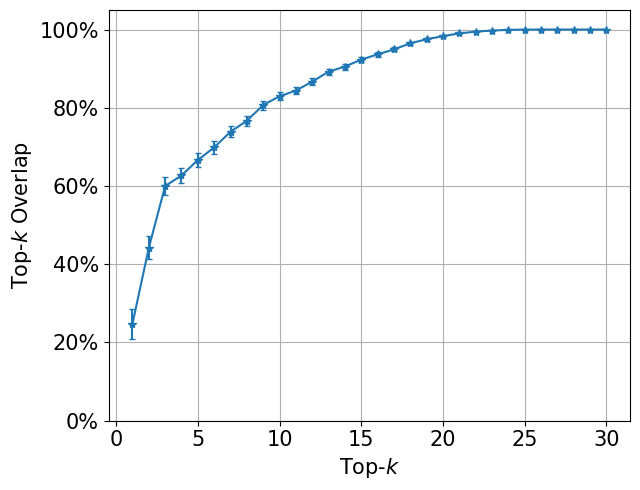

In [59]:
from matplotlib.ticker import PercentFormatter

height = 5
text_size, tick_size = height * 3, height * 3
fig, ax = plt.subplots(figsize=(height * 1.3, height))
ax.errorbar(np.arange(1, 31), np.mean(top_k_overlaps, axis=1),
            yerr=1.96 * np.std(top_k_overlaps, axis=1, ddof=1) / np.sqrt(len(top_k_overlaps[0])),
            fmt="*-C0", capsize=2)
ax.grid()
ax.set_xlabel("Top-$k$", fontsize=text_size)
ax.set_ylabel("Top-$k$ Overlap", fontsize=text_size)
ax.tick_params(labelsize=tick_size)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig(OUT_DIR / ".." / "visualizations" / "top_k_overlap.pdf")

# Most important rules and features

In [ ]:
pd.concat(metrics["rulefit"]["rule"]).sort_values("importance", ascending=False)

In [ ]:
pd.DataFrame({"feature": features, "importance": abs(W * D).mean(axis=0)}).sort_values("importance", ascending=False)

# Visualize scenario

In [ ]:
top_rule = pd.concat(metrics["rulefit"]["rule"]).sort_values("importance", ascending=False).iloc[0]
X.query(top_rule["rule"])

In [ ]:
from impl.ads.utils.visualization import visualize_scenario

visualize_scenario(solutions[360][0])